# Medidas de heterogeneidad

El objetivo de esta sección es calcular y analizar la diversidad y dispersión de las siguientes variables cualitativas del conjunto de datos:

* **Nivel socioeconómico y educativo:** `nivel_escolaridad`, `estrato_socioeconomico`
* **Estado civil:** `estado_civil_id`, `estado_civil_desc`
* **Dinámica laboral y económica:** `pareja_trabaja_id`, `pareja_trabaja_desc`, `dinero_propio_id`, `dinero_propio_desc`, `tiene_ahorros_id`, `tiene_ahorros_desc`, `propietaria_vivienda_id`, `propietaria_vivienda_desc`
* **Apoyo y bienestar:** `apoyo_gobierno_id`, `apoyo_gobierno_desc`, `sufrio_violencia_pareja`

Para medir el grado de heterogeneidad o diversidad de cada una, se emplearán tres indicadores estadísticos clave:
1. **Índice de Variación Cualitativa (IQV):** Mide la proporción de diferencias observadas en relación con el máximo posible. Oscila entre $0$ (homogeneidad total) y $1$ (máxima heterogeneidad).
2. **Índice de Gini-Simpson:** Evalúa la probabilidad de que dos elementos seleccionados al azar pertenezcan a categorías distintas.
3. **Entropía de Shannon:** Mide la incertidumbre o la cantidad de "información" contenida en la distribución de las categorías.

=== MEDIDAS DE heterogeneidad ===
shape: (15, 5)
┌───────────────────────────┬──────────────┬──────────────┬────────┬─────────────────┐
│ variable                  ┆ k_categorias ┆ Gini_Simpson ┆ IQV    ┆ Shannon_Entropy │
│ ---                       ┆ ---          ┆ ---          ┆ ---    ┆ ---             │
│ str                       ┆ i64          ┆ f64          ┆ f64    ┆ f64             │
╞═══════════════════════════╪══════════════╪══════════════╪════════╪═════════════════╡
│ dinero_propio_id          ┆ 2            ┆ 0.4976       ┆ 0.9952 ┆ 0.9965          │
│ dinero_propio_desc        ┆ 2            ┆ 0.4976       ┆ 0.9952 ┆ 0.9965          │
│ pareja_trabaja_id         ┆ 2            ┆ 0.4971       ┆ 0.9943 ┆ 0.9959          │
│ pareja_trabaja_desc       ┆ 2            ┆ 0.4971       ┆ 0.9943 ┆ 0.9959          │
│ propietaria_vivienda_id   ┆ 2            ┆ 0.4507       ┆ 0.9013 ┆ 0.9276          │
│ propietaria_vivienda_desc ┆ 2            ┆ 0.4507       ┆ 0.9013 ┆ 0.9276      

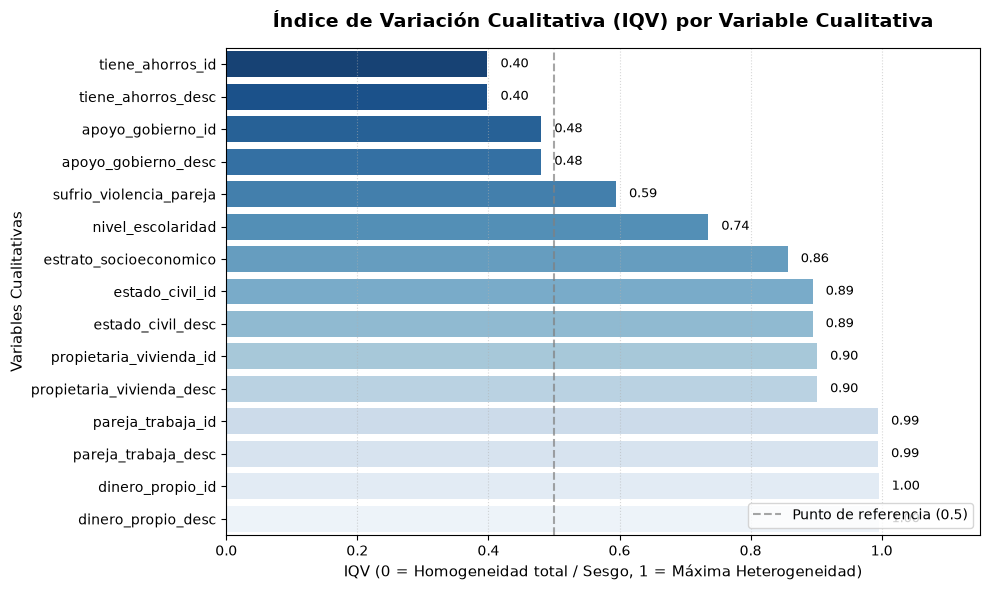

Polars 1.44.2; registros: 105,715


In [2]:
from pathlib import Path
import sys

PROYECTO = Path.cwd().resolve()
if PROYECTO.name == 'notebooks':
    PROYECTO = PROYECTO.parent
if str(PROYECTO) not in sys.path:
    sys.path.insert(0, str(PROYECTO))

import polars as pl
import polars.selectors as cs
from src.analysis.medidas_heterogeneidad import (
    cargar_datos,medidas_heterogeneidad,generar_grafica_iqv

)

df = cargar_datos()
heterogeneidad = medidas_heterogeneidad(df)
with pl.Config(tbl_rows=20, tbl_cols=20, float_precision=4):
        print("=== MEDIDAS DE heterogeneidad ===")
        print(heterogeneidad)
generar_grafica_iqv(heterogeneidad,show=True)
print(f'Polars {pl.__version__}; registros: {df.height:,}')

### Análisis e Interpretación de los Índices de Diversidad

A partir de los cálculos obtenidos para el Índice de Gini-Simpson, el Índice de Variación Cualitativa (IQV) y la Entropía de Shannon, se pueden destacar los siguientes patrones en los datos:

* **Máxima Diversidad Binaria ($K = 2$):**
  * Las variables **`pareja_trabaja`** y **`dinero_propio`** registran un IQV muy cercano a $1$ ($0.9943$ y $0.9952$) y una Entropía de Shannon cercana a su valor máximo teórico para dos categorías ($\approx 1.0$). Esto indica que las respuestas están **equitativamente distribuidas (casi un 50/50)** entre sus dos opciones.
  * La variable **`propietaria_vivienda`** también muestra un comportamiento equilibrado significativo (IQV de $0.90$).

* **Alta Heterogeneidad en Categorías Múltiples ($K = 6$ y $K = 4$):**
  * **`estado_civil`** presenta una alta diversidad (IQV de $0.89$ y Shannon de $2.22$), lo que significa que la población analizada se encuentra bien distribuida entre las diferentes categorías de estado civil en lugar de concentrarse en una sola.
  * **`estrato_socioeconomico`** ($K = 4$) también muestra una dispersión considerable (IQV de $0.86$).

* **Baja Diversidad y Fuerte Sesgo (Variables Asimétricas):**
  * Variables como **`apoyo_gobierno`** (IQV = $0.48$) y **`tiene_ahorros`** (IQV = $0.40$) muestran los índices más bajos del conjunto. Esto refleja un **fuerte sesgo o concentración** en una de las categorías (la gran mayoría de la población coincide en la misma respuesta para estos rubros).
  * **`sufrio_violencia_pareja`** muestra un comportamiento similar (IQV de $0.59$), indicando un predominio claro de una de las opciones sobre la otra.

# Desglose detallado por variable (Índices de Diversidad)

* **`nivel_escolaridad` ($K = 6$)**
  * *Gini-Simpson: 0.6127 | IQV: 0.7353 | Shannon: 1.8481*
  * **Significado:** Muestra una diversidad moderada-alta. La población encuestada no se concentra en un solo nivel educativo, sino que se distribuye de manera razonable entre las 6 categorías, aunque existen ciertas concentraciones preferentes.

* **`estado_civil_id` / `estado_civil_desc` ($K = 6$)**
  * *Gini-Simpson: 0.7455 | IQV: 0.8945 | Shannon: 2.2176*
  * **Significado:** Presenta una alta heterogeneidad (un IQV cercano a 0.90 y alta entropía). Las personas de la muestra están muy bien repartidas entre los diferentes estados civiles sin que ninguno domine de forma absoluta.

* **`estrato_socioeconomico` ($K = 4$)**
  * *Gini-Simpson: 0.6424 | IQV: 0.8565 | Shannon: 1.7136*
  * **Significado:** Buena dispersión entre los 4 estratos. El IQV de 0.85 indica que hay una representación equilibrada de diferentes niveles socioeconómicos en la base de datos.

* **`pareja_trabaja_id` / `pareja_trabaja_desc` ($K = 2$)**
  * *Gini-Simpson: 0.4971 | IQV: 0.9943 | Shannon: 0.9959*
  * **Significado:** Comportamiento casi perfecto de 50/50. El IQV cercano a 1.0 y la entropía máxima indican que la mitad de las parejas trabajan y la otra mitad no, mostrando una división totalmente equitativa.

* **`dinero_propio_id` / `dinero_propio_desc` ($K = 2$)**
  * *Gini-Simpson: 0.4976 | IQV: 0.9952 | Shannon: 0.9965*
  * **Significado:** Al igual que el anterior, presenta una distribución simétrica casi exacta (50/50). Las respuestas sobre tener o no dinero propio están completamente divididas en la población analizada.

* **`apoyo_gobierno_id` / `apoyo_gobierno_desc` ($K = 2$)**
  * *Gini-Simpson: 0.2403 | IQV: 0.4806 | Shannon: 0.5834*
  * **Significado:** Baja heterogeneidad y fuerte sesgo. Con un IQV de 0.48, se observa que la gran mayoría de las personas coincide en la misma respuesta (la inmensa mayoría no recibe apoyo del gobierno).

* **`tiene_ahorros_id` / `tiene_ahorros_desc` ($K = 2$)**
  * *Gini-Simpson: 0.1992 | IQV: 0.3984 | Shannon: 0.5064*
  * **Significado:** Es la variable con menor diversidad de todo el conjunto. El IQV de 0.39 refleja una concentración drástica: la gran mayoría de la población comparte la misma condición respecto a los ahorros (no tienen).

* **`propietaria_vivienda_id` / `propietaria_vivienda_desc` ($K = 2$)**
  * *Gini-Simpson: 0.4507 | IQV: 0.9013 | Shannon: 0.9276*
  * **Significado:** Alta heterogeneidad para ser una variable binaria. Un IQV de 0.90 muestra que, aunque hay un ligero sesgo, las opciones de ser o no propietaria de vivienda están bastante repartidas.

* **`sufrio_violencia_pareja` ($K = 2$)**
  * *Gini-Simpson: 0.2973 | IQV: 0.5945 | Shannon: 0.6836*
  * **Significado:** Heterogeneidad media-baja. Con un IQV de 0.59, se evidencia un sesgo importante hacia una de las opciones (lo que indica estadísticamente que la categoría de "no" reportar violencia domina de manera clara en la muestra).